<table border=0 width="100%"><tr><td><p align="left"><img src="..\img\logo.png" align="left" width=300></p></td><td><font size=3><B>量化交易基础（郑海超）</B></font></td></tr></table>

# 内容
- 量化交易
- 交易策略评估
- 移动均线策略
- 交易策略回测注意事项

# 文献分享
- 文献分享：Are Monthly Seasonals Real? A Three Century Perspective

# 量化交易

## 基本框架

关注量化交易的原因：
- 算法交易通过加快价格发现提高信息效率。对于市值较小、流动性较低且容易被忽略的公司，统计套利者（也称为配对交易）是主要的市场流动性提供者，这样可以帮助市场参与者发现有效的市场价格。  例如：两个基本面相似的公司（A和B），股票A被指数收录，由于指数基金会购买A，因此供求关系导致A公司的价格比B公司高。可以卖出股票A，买入股票B。
- 量化交易有助于推动我们深入思考，这是一个解决问题的系统化方法。例如：如何在统计套利交易中，如何判定两种金融产品的相似性，以及何种因素驱使价格背离。
- 人们具有推理、创造、从历史经验中学习的能力，因此在计划的筹备阶段，人们都有长项。但是在计划的执行阶段，常常缺乏纪律性。“亏损时要及时止损，英力士要让利润奔跑”，但是人工执行交易时，很难完全做到。

<img src="../img/量化交易黑箱.png" align='left' height="300" width="500"/>

阿尔法代表的最普遍的意思是超额回报。

如果基金经理的工作只是购买一个指数ETF的话，那么他显然是不合格的。投资者被钱交给基金经理的唯一原因，是经理可以给予投资者比市场更好的回报。而这个更好的回报，我们就把它称之为超额回报，简称阿尔法(α)。

阿尔法模型代表乐观指数，考虑交易的金融产品的未来趋势。
- 理论驱动型
- 数据驱动型

同时还要考虑：
- 风险，例如要控制必要的交易规模
- 成本，例如交易佣金、滑点、市场冲击成本

## 投资策略

对我们而言，算法交易策略，是由python代码表述，根据新数据决定在合适的时机买入或卖出某个或某些合适的金融资产，建立多头、空头头寸。

- 信号（Signal）：如何判断买/卖机会

- 投资组合构建（portfolio）：决定“买卖什么”和“买卖多少”

- 交易执行（Execution）：买多少、如何降低滑点、成本

- 风险控制（Risk Control）：什么时候止损、何时减少仓位

我们进行金融数据分析，特别是量化交易编程，对于我们的思维逻辑训练是非常有用的
- 你不能简单地告诉计算机“请帮我发现廉价的股票”。 你要用程序打开这个黑箱：从什么数据发现，如何代表廉价，股票池是什么？
- 你不能简单地告诉计算机“请帮我在合适的时间买卖这些股票”。你要编程导入行情等数据，度量合适的指标，预测牛熊转换，选择何时时间点，然后下单交易

https://quote.eastmoney.com/zs000001.html#fullScreenChart

<img src="../img/阿尔法模型.png" align='left' height="300" width="450"/>

## 量化交易策略研究的步骤
* 获取并分析数据，并构建交易策略。这一步是非常重要，涉及数据和模型。关于模型，我们重点关注阿尔法模型（关注金融产品的未来趋势）。
* 策略回测：设置策略回测起始日期（历史数据）、初始资金、回测频率（天、分钟）
* 策略分析：策略回测报告，包括收益概况、交易明细、历史持仓、日志输出、风险指标评价、归因分析报告
* 模拟交易、实盘交易

这是一个循环、迭代的过程，并非是线性的。

# 交易策略评估

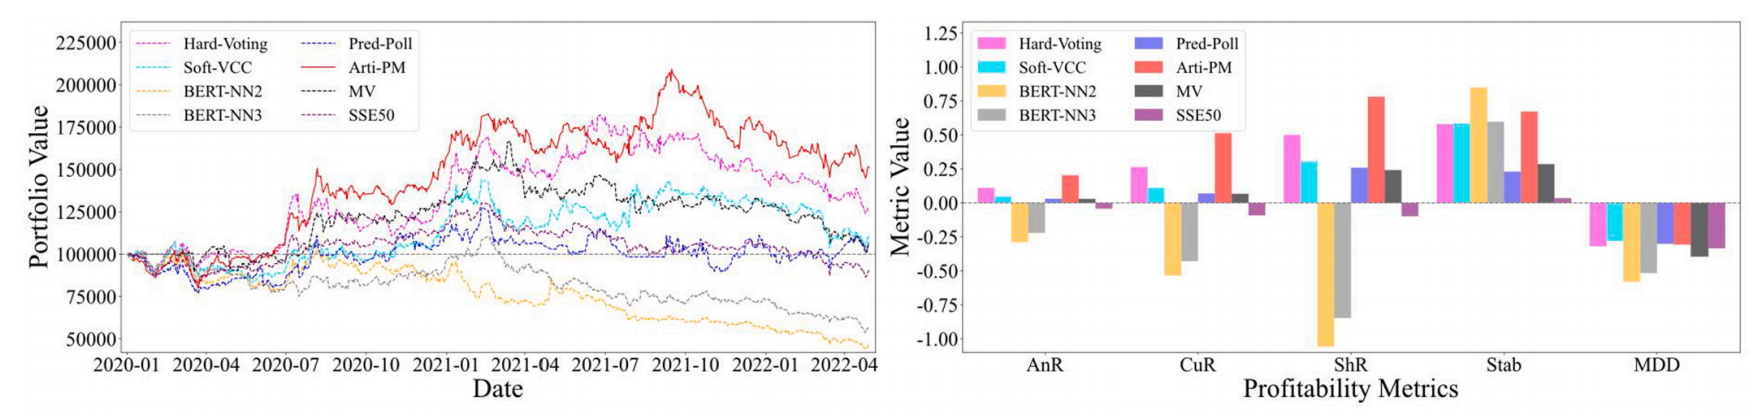

常见的策略回测评估指标
- 累计盈利图
- 最大回撤
- 胜率或盈利时间占比
- 回报相对于风险的不同比率
- 特定参数的敏感性

## 基准策略：Buy and Hold

Buy and Hold 的规则非常简单：

- 买入某个资产（如股票、指数基金、ETF）

- 长期持有，不因为短期波动卖出

- 不择时、不频繁换仓

- 直到你的投资期限结束才卖出（如 10 年、20 年）

### 准备数据

- sse_daily_index

In [3]:
import pandas as pd
sse_index = pd.read_csv("sse_daily_index.csv", index_col='trade_date', parse_dates=['trade_date'])

In [4]:
sse_index.sort_index(inplace = True)

In [5]:
sse_index

,Unnamed: 0,ts_code,close,open,high,low,pre_close,change,pct_chg,vol,amount
trade_date,,,,,,,,,,,
2000-01-04,6284,000001.SH,1406.3710,1368.6930,1407.5180,1361.2140,1366.5800,39.7910,2.9117,9034023.0,5.183898e+06
2000-01-05,6283,000001.SH,1409.6820,1407.8290,1433.7800,1398.3230,1406.3710,3.3110,0.2354,10579984.0,8.137326e+06
2000-01-06,6282,000001.SH,1463.9420,1406.0360,1463.9550,1400.2530,1409.6820,54.2600,3.8491,13480515.0,9.520842e+06
2000-01-07,6281,000001.SH,1516.6040,1477.1540,1522.8250,1477.1540,1463.9420,52.6620,3.5973,34515699.0,1.948719e+07
2000-01-10,6280,000001.SH,1545.1120,1531.7120,1546.7230,1506.4040,1516.6040,28.5080,1.8797,31253539.0,1.877911e+07
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-03,4,000001.SH,3877.9996,3894.1556,3901.6960,3869.9528,3897.7116,-19.7120,-0.5057,485617270.0,6.471665e+08
2025-12-04,3,000001.SH,3875.7933,3879.7417,3888.8595,3859.0491,3877.9996,-2.2063,-0.0569,445040290.0,6.237126e+08
2025-12-05,2,000001.SH,3902.8076,3873.1207,3907.7816,3863.3137,3875.7933,27.0143,0.6970,500368768.0,7.167424e+08


### 可视化收盘价趋势

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 设置中文字体，提供多种备选字体以确保兼容性
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题


<Axes: xlabel='trade_date'>

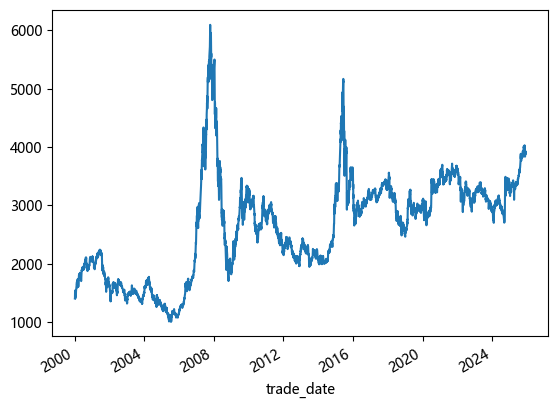

In [7]:
sse_index["close"].plot(label = "close")

### 准备策略评估函数

#### 累计盈利图 - 一图胜千言，从盈利图可以刊出，策略能否盈利、平稳性。

<img src = "../img/累计盈利图.png" align='left' height="400" width="500"/>

#### calculate_log_returns

In [8]:
import numpy as np
import pandas as pd

In [9]:
def calculate_log_returns(price_series):
    """
    计算对数收益率序列
    参数：
        price_series: pd.Series，包含价格数据（通常是收盘价），索引应为日期时间类型
    返回：
        pd.Series，对数收益率序列
    """
    return np.log(price_series / price_series.shift(1))

#### annualized_return

In [10]:
def annualized_return(log_returns, periods_per_year=252):
    """
    计算年化收益率
    参数：
        log_returns: pd.Series，对数收益率序列
        periods_per_year: int，年化周期数（默认252个交易日）
    返回：
        float，年化收益率
    """
    total_return = log_returns.sum()
    years = len(log_returns) / periods_per_year
    return np.exp(total_return / years) - 1

#### annualized_volatility

In [12]:
def annualized_volatility(log_returns, periods_per_year=252):
    """
    计算年化波动率
    参数：
        log_returns: pd.Series，对数收益率序列
        periods_per_year: int，年化周期数（默认252个交易日）
    返回：
        float，年化波动率
    """
    return log_returns.std() * np.sqrt(periods_per_year)

#### sharpe_ratio

- 无风险利率2%

In [13]:
def sharpe_ratio(log_returns, risk_free_rate=0.02, periods_per_year=252):
    """
    计算夏普比率
    参数：
        log_returns: pd.Series，对数收益率序列
        risk_free_rate: float，年化无风险利率（默认2%）
        periods_per_year: int，年化周期数（默认252个交易日）
    返回：
        float，夏普比率
    """
    excess_return = annualized_return(log_returns, periods_per_year) - risk_free_rate
    volatility = annualized_volatility(log_returns, periods_per_year)
    return excess_return / volatility

#### max_drawdown

In [14]:
def max_drawdown(net_value):
    """
    计算最大回撤
    参数：
        net_value: pd.Series，价格序列（如收盘价），索引应为日期
        对于其他投资策略，这个应该是模拟账户的净值曲线。根据信号模拟交易后，账户总资产每日的变化。
    返回：
        tuple，包含 (最大回撤值, 最大回撤开始日期, 最大回撤结束日期)
    """
    # 计算累积最大值（到当前日期为止的历史最高点）
    cumulative_max = net_value.expanding().max()
    # 计算每个时间点的回撤（从最高点的下跌幅度）
    drawdown = (net_value - cumulative_max) / cumulative_max
    # 找到最大回撤及其位置
    max_dd = drawdown.min()
    end_date = drawdown.idxmin()
    # 寻找最大回撤开始日期（回撤开始前的最后一个高点日期）
    start_date = net_value[:end_date].idxmax() if not pd.isnull(end_date) else None
    return max_dd, start_date, end_date

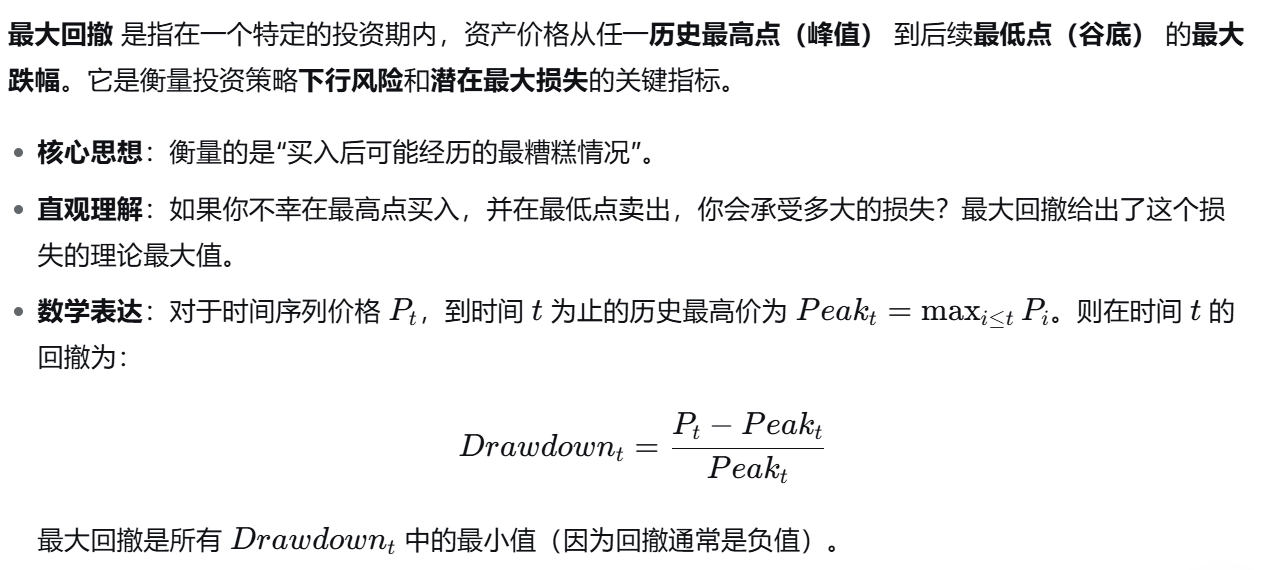


函数计算细节分步解析
下面我们逐行拆解你给出的函数，并用一个简单的例子来说明。

```python
def max_drawdown(price_series):
    # 假设 price_series = [100, 110, 105, 90, 95, 80, 85]
    # 对应的日期索引为 [D1, D2, D3, D4, D5, D6, D7]

    # 1. 计算累积最大值（到当前日期为止的历史最高点）
    # expanding().max() 会计算从序列开始到当前行的最大值
    cumulative_max = price_series.expanding().max()
    # 结果: [100, 110, 110, 110, 110, 110, 110]
    # 解读：到D2时，历史最高是110；之后直到D7，历史最高都维持在110

    # 2. 计算每个时间点的回撤（从最高点的下跌幅度）
    drawdown = (price_series - cumulative_max) / cumulative_max
    # 计算过程示例 (D4): (90 - 110) / 110 = -0.1818
    # 结果: [0.0, 0.0, -0.0455, -0.1818, -0.1364, -0.2727, -0.2273]

    # 3. 找到最大回撤及其位置
    max_dd = drawdown.min()  # 最小值: -0.2727 (即 -27.27%)
    end_date = drawdown.idxmin()  # 最小值索引: D6 (回撤结束的谷底日期)

    # 4. 寻找最大回撤开始日期（回撤开始前的最后一个高点日期）
    # price_series[:end_date] 是到D6（不含D6）之前的所有价格
    # .idxmax() 找出这个子序列中最大值的索引，即峰值日期
    start_date = price_series[:end_date].idxmax() if not pd.isnull(end_date) else None
    # 到D6之前的价格: [100, 110, 105, 90, 95]，最大值110在 D2

    return max_dd, start_date, end_date
    # 返回: (-0.2727, D2, D6)
```

#### plot

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

def plot_wealth_from_log_returns(log_return_series,
                                 initial_capital=100000,
                                 title='Strategy Wealth Growth (Based on Log Returns)',
                                 figsize=(10, 6)):
    # 1. Ensure data is sorted and work on a copy
    log_returns = log_return_series.sort_index().copy()

    # 2. Calculate cumulative wealth (Core step)
    cumulative_log_return = log_returns.cumsum()
    wealth_series = initial_capital * np.exp(cumulative_log_return)

    # 3. Create plot
    fig, ax = plt.subplots(figsize=figsize)

    # 4. Plot wealth curve
    ax.plot(wealth_series.index, wealth_series.values)

    # 5. Calculate and display key statistics
    total_return_log = log_returns.sum()
    total_return = np.exp(total_return_log) - 1
    final_wealth = wealth_series.iloc[-1]

    # Calculate annualized return (assuming 252 trading days)
    if len(log_returns) > 252:
        annualized_return = np.exp(log_returns.mean() * 252) - 1
        return_info = f'Ann. Return: {annualized_return:.1%}'
    else:
        return_info = ''

    stats_text = f'''Initial Capital: ¥{initial_capital:,.0f}
Final Wealth: ¥{final_wealth:,.0f}
Total Return: {total_return:+.1%}
{return_info}'''

    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9),
            family='monospace')

    # 6. Format the chart
    ax.set_xlabel('Date')
    ax.set_ylabel('Wealth (¥)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--', zorder=1)

    # Format x-axis dates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    fig.autofmt_xdate(rotation=30, ha='right')

    # Format y-axis as currency
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'¥{x:,.0f}'))

    plt.tight_layout()
    return fig, ax, wealth_series

### 评估hold and buy策略

In [16]:
# 1. 确保数据按日期排序（升序，从过去到现在）
sse_index = sse_index.sort_index()

In [17]:
# 2. 提取收盘价序列
close_prices = sse_index['close']

In [18]:
# 3. 计算对数收益率序列
log_ret = calculate_log_returns(close_prices)

# 4. 计算各项指标（需要剔除NaN值，即收益率序列的第一个值）
log_ret_clean = log_ret.dropna()

annual_ret = annualized_return(log_ret_clean)
annual_vol = annualized_volatility(log_ret_clean)
sharpe = sharpe_ratio(log_ret_clean)

# 
initial_capital = 100000
cumulative_log_return = log_ret_clean.cumsum()
net_value = initial_capital * np.exp(cumulative_log_return)

max_dd, start_date, end_date = max_drawdown(net_value)

# 5. 打印结果
print(f"策略表现评估 (基于对数收益率)")
print("=" * 40)
print(f"年化收益率: {annual_ret:.2%}")
print(f"年化波动率: {annual_vol:.2%}")
print(f"夏普比率 (无风险利率2%): {sharpe:.2f}")
print(f"最大回撤: {max_dd:.2%}")
print(f"最大回撤期: {start_date.date()} 至 {end_date.date()}")

策略表现评估 (基于对数收益率)
年化收益率: 4.19%
年化波动率: 23.17%
夏普比率 (无风险利率2%): 0.09
最大回撤: -71.98%
最大回撤期: 2007-10-16 至 2008-11-04


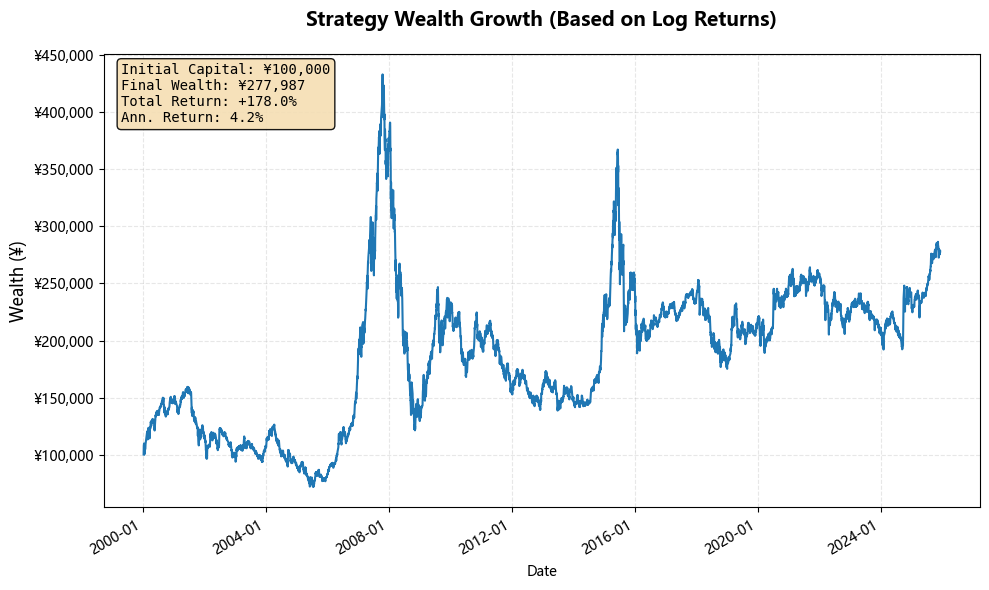

初始财富: ￥100235.43
最终财富: ￥277986.51
总收益率: 177.33%


In [19]:
# 假设你已经有对数收益率序列 `log_ret` (pd.Series, 索引为日期)
# 可以使用之前定义的 calculate_log_returns 函数计算得到

# 调用函数绘图
fig, ax, wealth_series = plot_wealth_from_log_returns(
    log_return_series=log_ret_clean,
)

plt.show()

# 可以查看计算出的财富值序列
print(f"初始财富: ￥{wealth_series.iloc[0]:.2f}")
print(f"最终财富: ￥{wealth_series.iloc[-1]:.2f}")
print(f"总收益率: {(wealth_series.iloc[-1]/wealth_series.iloc[0]-1):.2%}")

# 整合的策略评估函数

In [20]:
def strategy_evaluate(log_ret_clean, net_value):

    annual_ret = annualized_return(log_ret_clean)
    annual_vol = annualized_volatility(log_ret_clean)
    sharpe = sharpe_ratio(log_ret_clean)
    max_dd, start_date, end_date = max_drawdown(net_value)

    # 5. 打印结果
    print(f"策略表现评估 (基于对数收益率)")
    print("=" * 40)
    print(f"年化收益率: {annual_ret:.2%}")
    print(f"年化波动率: {annual_vol:.2%}")
    print(f"夏普比率 (无风险利率2%): {sharpe:.2f}")
    print(f"最大回撤: {max_dd:.2%}")
    print(f"最大回撤期: {start_date.date()} 至 {end_date.date()}")
    
    # 调用函数绘图
    fig, ax, wealth_series = plot_wealth_from_log_returns(log_return_series=log_ret_clean)

    plt.show()

    # 可以查看计算出的财富值序列
    print(f"初始财富: ￥{wealth_series.iloc[0]:.2f}")
    print(f"最终财富: ￥{wealth_series.iloc[-1]:.2f}")
    print(f"总收益率: {(wealth_series.iloc[-1]/wealth_series.iloc[0]-1):.2%}")
    
    return {"annual_ret":annual_ret,
            "annual_volitity":annual_vol,
            "sharpe":sharpe,
            "max_dd":max_dd,
            "wealth_series":wealth_series.iloc[-1]
           }

## 课堂实验：标普500指数实验 buy and hold策略
- 计算年化收益率
- 年化波动率
- 夏普比率（无风险利率2%）
- 最大最大回撤

In [31]:
# 读取数据
spx = pd.read_csv("spx.csv", index_col = "trade_date", parse_dates=['trade_date'])

spx_close_price = spx['close']

log_ret_spx = np.log(spx_close_price / spx_close_price.shift(1))

log_ret_clean_spx = log_ret_spx.dropna()

<Axes: title={'center': 'S&P 500 Close Price'}, xlabel='trade_date'>

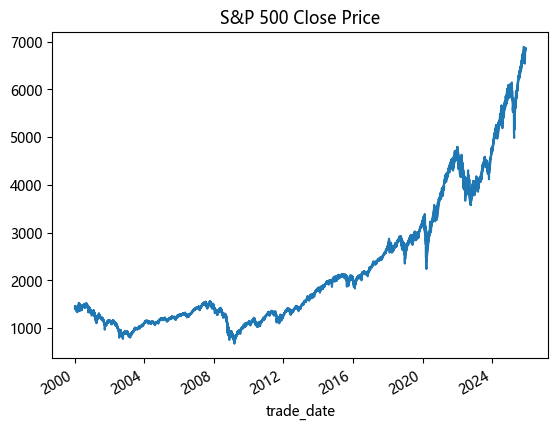

In [32]:
# 可视化收盘价数据
spx_close_price.plot(title="S&P 500 Close Price")



In [28]:
# 评估标普500 buy and hold策略
net_value_spx = spx_close_price



策略表现评估 (基于对数收益率)
年化收益率: 6.32%
年化波动率: 29.03%
夏普比率 (无风险利率2%): 0.15
最大回撤: -56.78%
最大回撤期: 2007-10-09 至 2009-03-09


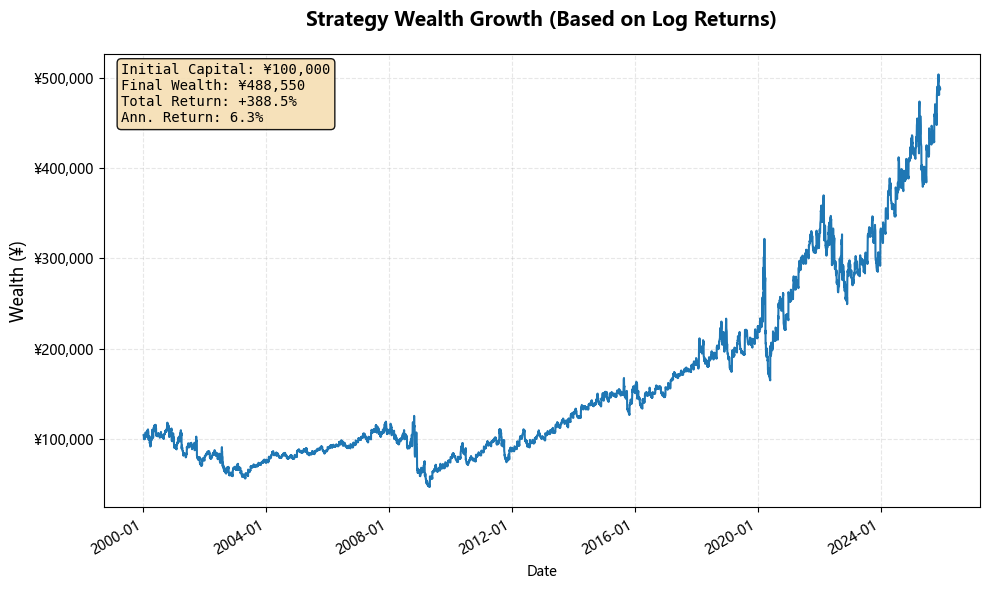

初始财富: ￥103987.37
最终财富: ￥488549.69
总收益率: 369.82%


{'annual_ret': np.float64(0.06320832630802742),
 'annual_volitity': np.float64(0.29028553800460183),
 'sharpe': np.float64(0.1488476711758973),
 'max_dd': -0.5677538894035716,
 'wealth_series': np.float64(488549.68948553834)}

In [33]:
# 可视化财富波动
strategy_evaluate(log_ret_clean_spx,net_value = net_value_spx)



# 移动均线策略

## 设计购买与持有信号

In [34]:
SMA_Short =20
SMA_Long = 100

In [35]:
sse_index["SMA_Short"] = sse_index.close.rolling(window=SMA_Short).mean()
sse_index["SMA_Long"] = sse_index.close.rolling(window=SMA_Long).mean()

<Axes: xlabel='trade_date'>

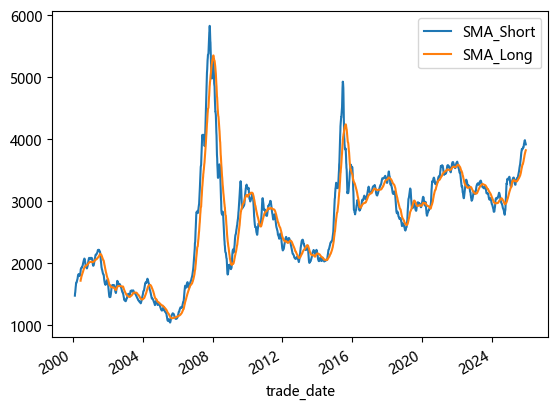

In [36]:
sse_index.loc[:,["SMA_Short","SMA_Long"]].plot()

sse_index['SMA_Short'] > sse_index['SMA_Long']

In [38]:
# 生成交易信号 (1:买入/持有, 0:卖出/空仓)
# 当短期均线上穿长期均线时买入并持有
sse_index['Signal'] = 0    
condition = (sse_index['SMA_Short'] > sse_index['SMA_Long']) & (sse_index['SMA_Short'].shift(1) <= sse_index['SMA_Long'].shift(1))
sse_index.loc[condition, 'Signal'] = 1

In [39]:
sse_index

,Unnamed: 0,ts_code,close,open,high,low,pre_close,change,pct_chg,vol,amount,SMA_Short,SMA_Long,Signal
trade_date,,,,,,,,,,,,,,
2000-01-04,6284,000001.SH,1406.3710,1368.6930,1407.5180,1361.2140,1366.5800,39.7910,2.9117,9034023.0,5.183898e+06,NaN,NaN,0
2000-01-05,6283,000001.SH,1409.6820,1407.8290,1433.7800,1398.3230,1406.3710,3.3110,0.2354,10579984.0,8.137326e+06,NaN,NaN,0
2000-01-06,6282,000001.SH,1463.9420,1406.0360,1463.9550,1400.2530,1409.6820,54.2600,3.8491,13480515.0,9.520842e+06,NaN,NaN,0
2000-01-07,6281,000001.SH,1516.6040,1477.1540,1522.8250,1477.1540,1463.9420,52.6620,3.5973,34515699.0,1.948719e+07,NaN,NaN,0
2000-01-10,6280,000001.SH,1545.1120,1531.7120,1546.7230,1506.4040,1516.6040,28.5080,1.8797,31253539.0,1.877911e+07,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-03,4,000001.SH,3877.9996,3894.1556,3901.6960,3869.9528,3897.7116,-19.7120,-0.5057,485617270.0,6.471665e+08,3934.794060,3803.792911,0
2025-12-04,3,000001.SH,3875.7933,3879.7417,3888.8595,3859.0491,3877.9996,-2.2063,-0.0569,445040290.0,6.237126e+08,3928.195730,3807.620349,0
2025-12-05,2,000001.SH,3902.8076,3873.1207,3907.7816,3863.3137,3875.7933,27.0143,0.6970,500368768.0,7.167424e+08,3923.458325,3811.551607,0


## 计算策略对应的每天的对数收益率

In [40]:
# 计算策略收益率
sse_index['Log_Return'] = np.log(sse_index['close'] / sse_index['close'].shift(1))

当日收益率 = 信号(t-1) * 当日对数收益率

In [64]:
# 当日收益率 = 信号(t-1) * 当日对数收益率
sse_index_clean['Strategy_Log_Return'] = sse_index_clean['Signal'].shift(1) * sse_index_clean['Log_Return']




C:\Users\Nanzheng\AppData\Local\Temp\ipykernel_3284\1919675791.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sse_index_clean['Strategy_Log_Return'] = sse_index_clean['Signal'].shift(1) * sse_index_clean['Log_Return']


In [63]:
print(sse_index_clean.columns)


Index(['Unnamed: 0', 'ts_code', 'close', 'open', 'high', 'low', 'pre_close',
       'change', 'pct_chg', 'vol', 'amount', 'SMA_Short', 'SMA_Long', 'Signal',
       'Log_Return'],
      dtype='object')


In [42]:
sse_index_clean = sse_index.dropna()

## 评估双均线策略

In [45]:
initial_capital = 100000
cumulative_log_return = sse_index['Strategy_Log_Return'].cumsum()
strategy_net_value = initial_capital * np.exp(cumulative_log_return)

策略表现评估 (基于对数收益率)
年化收益率: -0.17%
年化波动率: 1.16%
夏普比率 (无风险利率2%): -1.86
最大回撤: -5.59%
最大回撤期: 2001-03-30 至 2020-06-15


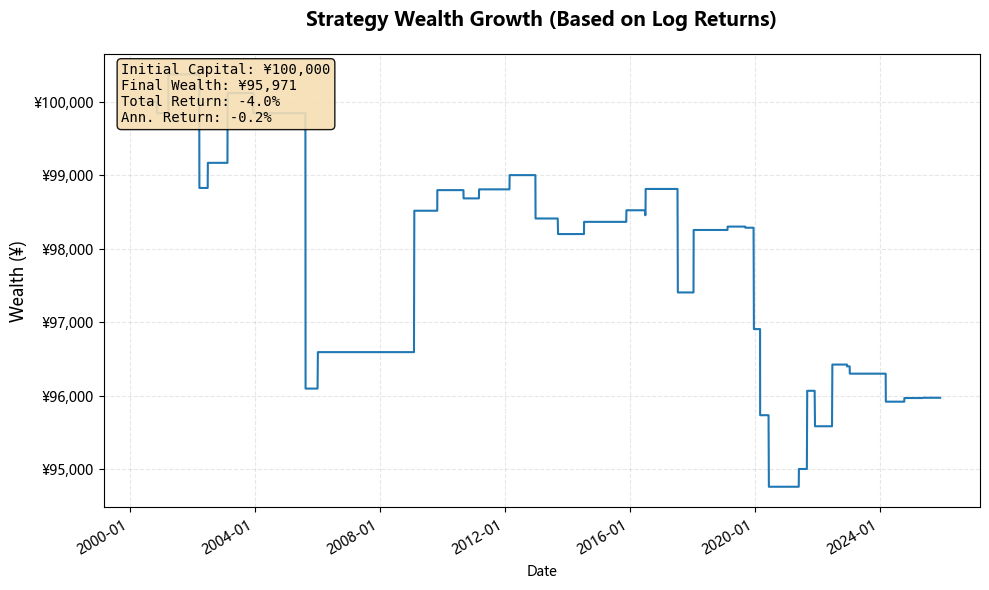

初始财富: ￥nan
最终财富: ￥95971.17
总收益率: nan%


In [65]:
log_ret_clean = sse_index_clean["Strategy_Log_Return"]

result1 = strategy_evaluate(log_ret_clean, net_value=strategy_net_value)

In [66]:
result1

{'annual_ret': np.float64(-0.001673805806967854),
 'annual_volitity': np.float64(0.011633809708296129),
 'sharpe': np.float64(-1.8630015747560453),
 'max_dd': -0.05593379322745735,
 'wealth_series': np.float64(95971.16805872321)}

策略表现评估 (基于对数收益率)
年化收益率: 4.19%
年化波动率: 23.17%
夏普比率 (无风险利率2%): 0.09
最大回撤: -71.98%
最大回撤期: 2007-10-16 至 2008-11-04


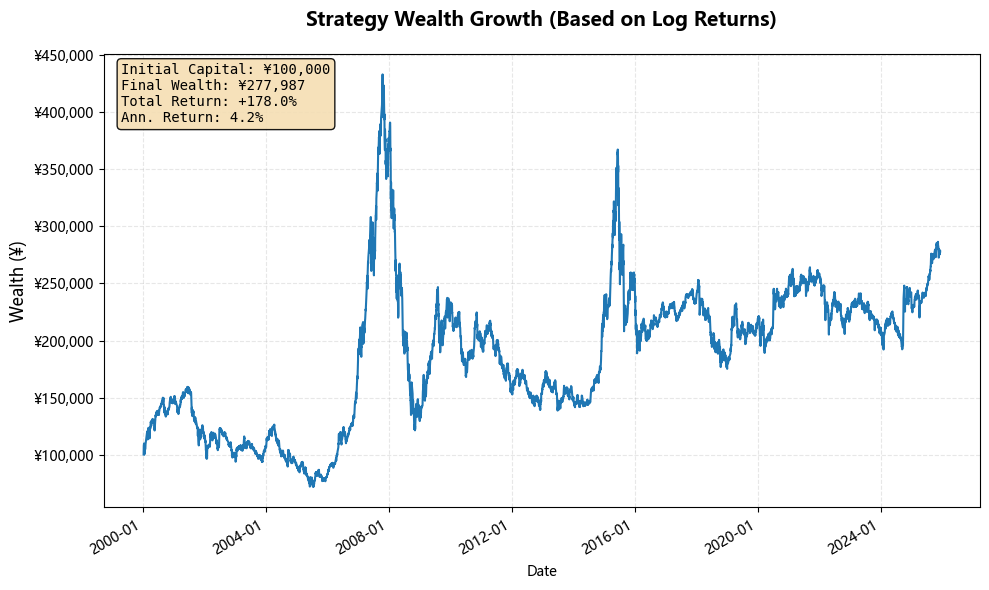

初始财富: ￥100235.43
最终财富: ￥277986.51
总收益率: 177.33%


In [67]:
log_ret_clean = sse_index["Log_Return"].dropna()
initial_capital = 100000
cumulative_log_return = sse_index['Log_Return'].cumsum()
net_value = initial_capital * np.exp(cumulative_log_return)


result2= strategy_evaluate(log_ret_clean, net_value=net_value)

In [68]:
# 将字典放入列表，创建DataFrame
df = pd.DataFrame([result1, result2], index = ["moving average","buy and hold"])
print(df)

                annual_ret  annual_volitity    sharpe    max_dd  wealth_series
moving average   -0.001674         0.011634 -1.863002 -0.055934   95971.168059
buy and hold      0.041852         0.231673  0.094324 -0.719848  277986.505694


## 移动平均线策略函数

In [72]:
def moving_average_strategy(price_series, short_window=20, long_window=100, start_date=None):
    """
    双均线策略（SMA）
    """
    import numpy as np
    import pandas as pd

    # 初始资金
    initial_capital = 100000

    # 准备价格数据
    prices = price_series.sort_index()
    if start_date:
        prices = prices[prices.index >= start_date]

    # 构建 DataFrame
    df = pd.DataFrame({'Close': prices})
    df['SMA_Short'] = df['Close'].rolling(short_window).mean()
    df['SMA_Long'] = df['Close'].rolling(long_window).mean()

    # 信号：短期 > 长期 → 做多，否则空仓
    df['Signal'] = (df['SMA_Short'] > df['SMA_Long']).astype(int)

    # 日对数收益
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

    # 策略收益 = 昨天信号 × 今天收益
    df['Strategy_Log_Return'] = df['Signal'].shift(1) * df['Log_Return']

    # 删除 NaN
    df_clean = df.dropna()

    # ---------------------
    #   净值曲线计算
    # ---------------------

    # Buy & Hold
    net_value_buy_hold = initial_capital * np.exp(df_clean['Log_Return'].cumsum())

    # Strategy Net Value
    net_value_strategy = initial_capital * np.exp(df_clean['Strategy_Log_Return'].cumsum())

    # 输出结果字典
    results = {
        'price_series': df['Close'],
        'signal_series': df['Signal'],
        'log_returns': df_clean['Log_Return'],
        'strategy_log_returns': df_clean['Strategy_Log_Return'],
        'short_ma': df['SMA_Short'],
        'long_ma': df['SMA_Long'],
        'dates': df.index,
        'net_value_buy_hold': net_value_buy_hold,
        'net_value_strategy': net_value_strategy,
        'df': df
    }

    return results


In [73]:
results = moving_average_strategy(sse_index["close"])

In [74]:
results.keys()

dict_keys(['price_series', 'signal_series', 'log_returns', 'strategy_log_returns', 'short_ma', 'long_ma', 'dates', 'net_value_buy_hold', 'net_value_strategy', 'df'])

策略表现评估 (基于对数收益率)
年化收益率: 2.98%
年化波动率: 23.05%
夏普比率 (无风险利率2%): 0.04
最大回撤: -71.98%
最大回撤期: 2007-10-16 至 2008-11-04


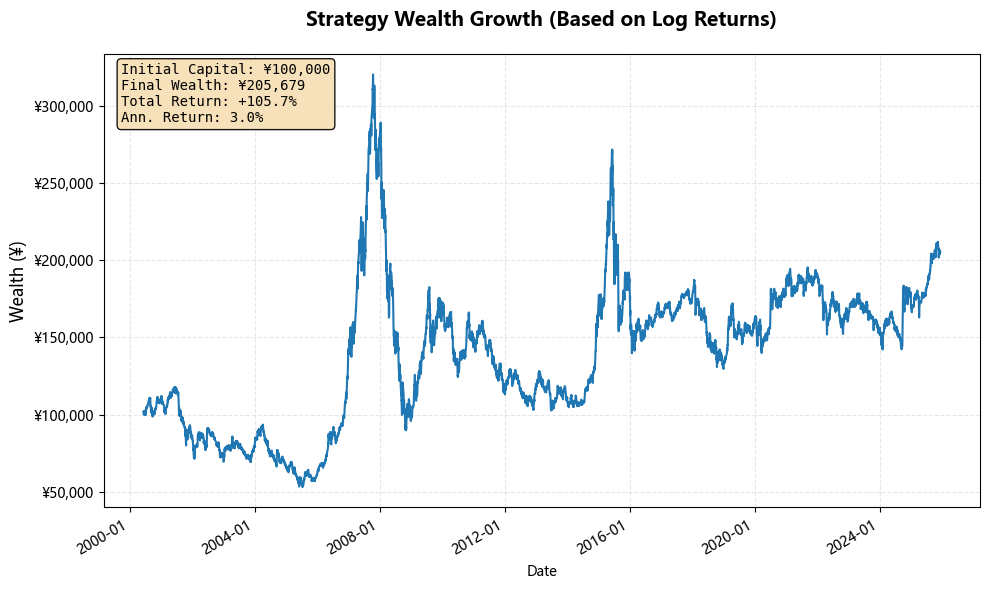

初始财富: ￥100619.22
最终财富: ￥205679.10
总收益率: 104.41%


{'annual_ret': np.float64(0.02981324726176582),
 'annual_volitity': np.float64(0.23045983931042038),
 'sharpe': np.float64(0.042581159872058044),
 'max_dd': -0.7198478280817133,
 'wealth_series': np.float64(205679.10028846134)}

In [75]:
# 评估双均线策略
strategy_evaluate(results.get("log_returns"), net_value= results.get("net_value_buy_hold"))

策略表现评估 (基于对数收益率)
年化收益率: 2.98%
年化波动率: 23.05%
夏普比率 (无风险利率2%): 0.04
最大回撤: -71.98%
最大回撤期: 2007-10-16 至 2008-11-04


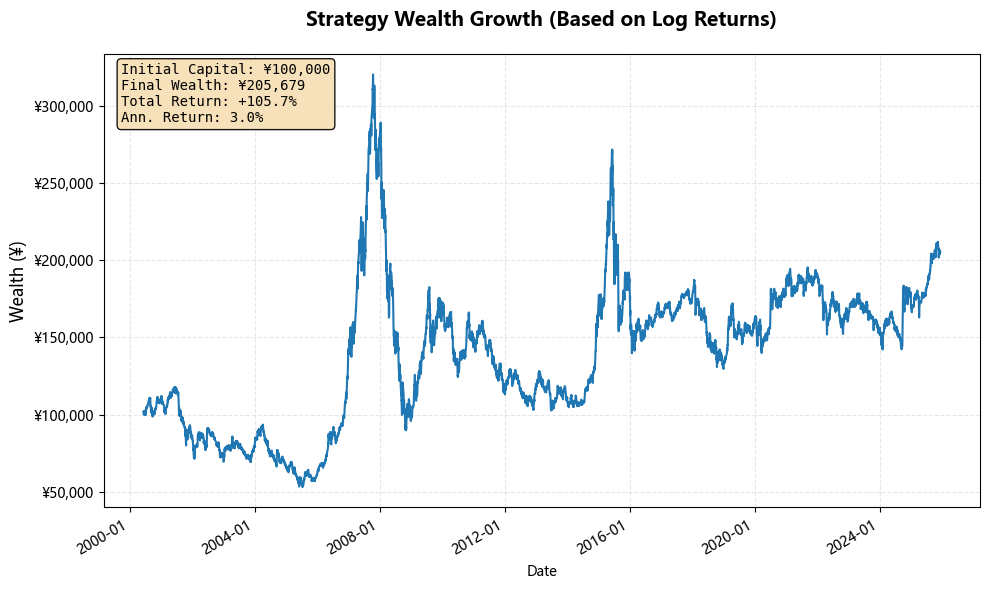

初始财富: ￥100619.22
最终财富: ￥205679.10
总收益率: 104.41%


{'annual_ret': np.float64(0.02981324726176582),
 'annual_volitity': np.float64(0.23045983931042038),
 'sharpe': np.float64(0.042581159872058044),
 'max_dd': -0.7198478280817133,
 'wealth_series': np.float64(205679.10028846134)}

In [76]:
strategy_evaluate(results.get("log_returns"), net_value= results.get("net_value_buy_hold"))

In [77]:
strategy_evaluate(results.get("strateby_log_returns"), net_value= results.get("net_value_strategy"))

AttributeError: 'NoneType' object has no attribute 'sum'

# 更多回测注意事项
- 时间窗口滑动
- 更多资产类型

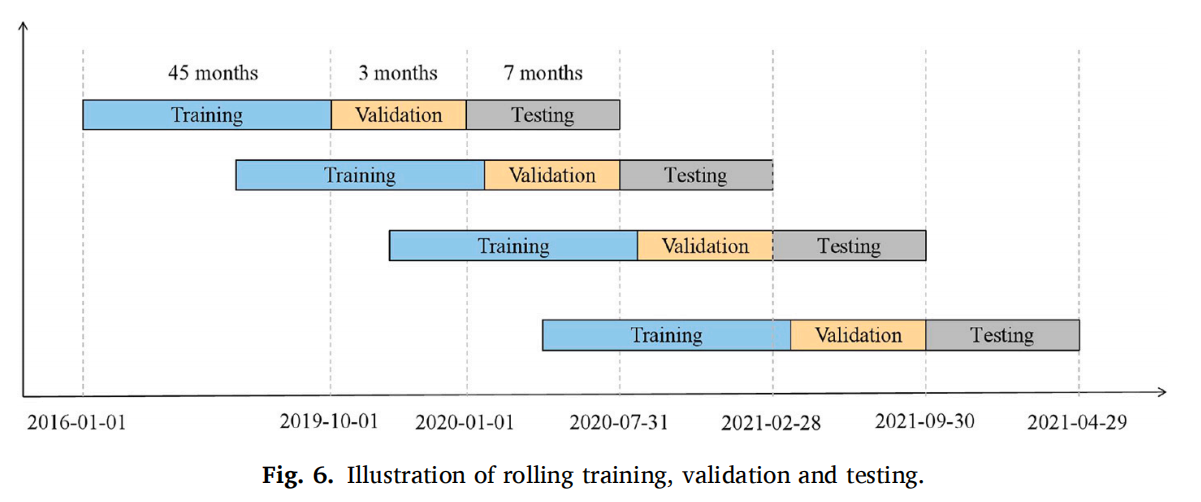

paper - Distilling wisdom of crowds in online communities: A novel prediction market constructed with comment posters

# 课堂实验 - 研究参数对于双均线策略的影响

- 调整short和long参数
- 评估不同short和long参数下均线策略的评估指标差异

In [78]:
# 开始编程
results = []

short_list = [5, 10, 20]
long_list = [30, 60, 120]

for s in short_list:
    for l in long_list:
        if s < l:   # 避免 short >= long
            perf = moving_average_strategy(sse_index_clean, s, l)
            results.append(perf)

results_df = pd.DataFrame(results)
results_df

results_df.sort_values('sharpe', ascending=False)






ValueError: If using all scalar values, you must pass an index

# 实验: 美国标普500指数相关的双均线策略评估

- 基于美国标普500指数做双均线策略
- 评估参数对策略的影响
- 评估策略的风险和收益
- 选取不同历史时期做策略评估

数据
- spx.csv

**邀请同学分享实验结果**

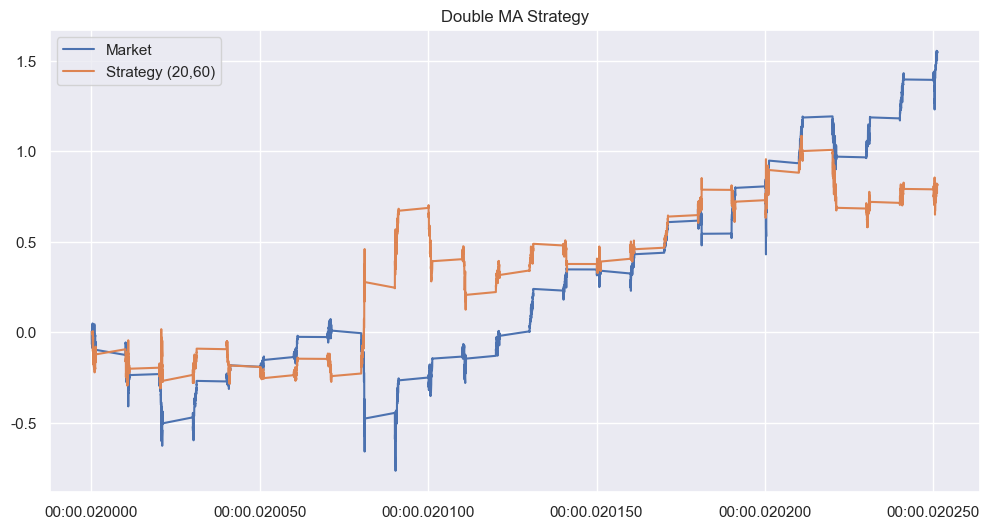

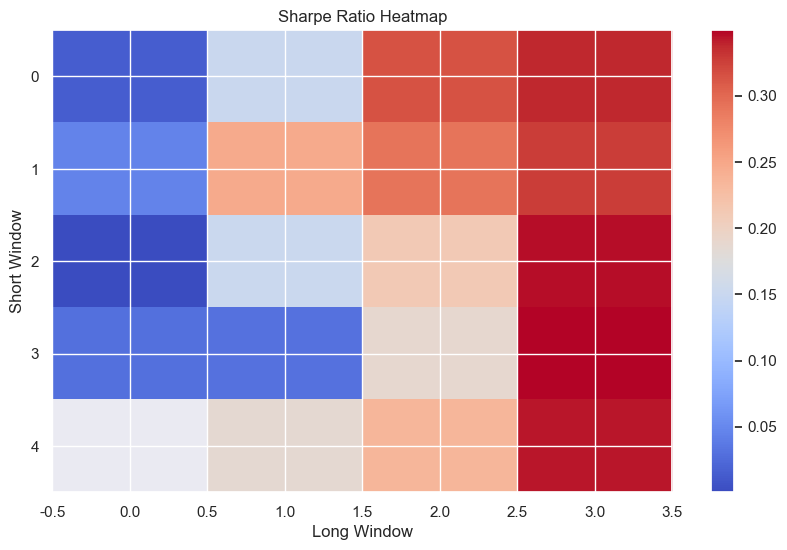

Dotcom (1995-2003) {'Annual Return': nan, 'Annual Vol': np.float64(nan), 'Sharpe': np.float64(nan), 'Max Drawdown': nan}
GFC (2007-2012) {'Annual Return': nan, 'Annual Vol': np.float64(nan), 'Sharpe': np.float64(nan), 'Max Drawdown': nan}
Post-COVID (2018-2023) {'Annual Return': nan, 'Annual Vol': np.float64(nan), 'Sharpe': np.float64(nan), 'Max Drawdown': nan}


In [91]:
#开始编程
#1.导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")


#2.读取数据并预处理
df = pd.read_csv("spx.csv")

# 替换成 trade_date（来自你的 CSV）
df['Date'] = pd.to_datetime(df['trade_date'])

df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# 用 close（你的 CSV 列名）
df['Return'] = np.log(df['close'] / df['close'].shift(1))


#3.定义策略函数
def double_ma_strategy(df, short=20, long=60):
    data = df.copy()
    
    data[f"MA_{short}"] = data['close'].rolling(short).mean()
    data[f"MA_{long}"] = data['close'].rolling(long).mean()

    # 交易信号：短期均线上穿长期均线 = 1；下穿 = -1
    data['Signal'] = 0
    data.loc[data[f"MA_{short}"] > data[f"MA_{long}"], 'Signal'] = 1
    data.loc[data[f"MA_{short}"] < data[f"MA_{long}"], 'Signal'] = -1

    # 策略收益（信号要滞后一天）
    data['Strategy_Return'] = data['Signal'].shift(1) * data['Return']

    return data


#4.单一参数组合的策略回测示例
res = double_ma_strategy(df, 20, 60)

res['Cum_Market'] = res['Return'].cumsum()
res['Cum_Strategy'] = res['Strategy_Return'].cumsum()

plt.figure(figsize=(12,6))
plt.plot(res['Cum_Market'], label='Market')
plt.plot(res['Cum_Strategy'], label='Strategy (20,60)')
plt.legend()
plt.title("Double MA Strategy")
plt.show()

#5.评估收益指标和风险指标
def evaluate(data):
    ann_return = data['Strategy_Return'].mean() * 252
    ann_vol = data['Strategy_Return'].std() * np.sqrt(252)
    sharpe = ann_return / ann_vol

    max_dd = (data['Strategy_Return'].cumsum() - 
              data['Strategy_Return'].cumsum().cummax()).min()

    return {
        "Annual Return": ann_return,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd
    }

metrics = evaluate(res)
metrics

short_list = [5, 10, 20, 30, 50]
long_list = [50, 100, 150, 200]

results = []

for s in short_list:
    for l in long_list:
        if s >= l:
            continue
        temp = double_ma_strategy(df, s, l)
        sharpe = temp['Strategy_Return'].mean() / temp['Strategy_Return'].std() * np.sqrt(252)
        results.append([s, l, sharpe])

heat = pd.DataFrame(results, columns=['Short', 'Long', 'Sharpe'])
heat_pivot = heat.pivot(index="Short", columns="Long", values="Sharpe")
heat_pivot

#6.参数敏感性分析
short_list = [5, 10, 20, 30, 50]
long_list = [50, 100, 150, 200]

results = []

for s in short_list:
    for l in long_list:
        if s >= l:
            continue
        temp = double_ma_strategy(df, s, l)
        sharpe = temp['Strategy_Return'].mean() / temp['Strategy_Return'].std() * np.sqrt(252)
        results.append([s, l, sharpe])

##画个热力图可视化一下
heat = pd.DataFrame(results, columns=['Short', 'Long', 'Sharpe'])
heat_pivot = heat.pivot(index="Short", columns="Long", values="Sharpe")
heat_pivot
plt.figure(figsize=(10,6))
plt.title("Sharpe Ratio Heatmap")
plt.xlabel("Long Window")
plt.ylabel("Short Window")
plt.imshow(heat_pivot, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.show()

#选择三个时段：1995-2003互联网泡沫大起大落；2007-2012金融危机；2018-2023疫情+加息
periods = {
    "Dotcom (1995-2003)": ("1995-01-01", "2003-12-31"),
    "GFC (2007-2012)": ("2007-01-01", "2012-12-31"),
    "Post-COVID (2018-2023)": ("2018-01-01", "2023-12-31")
}

for name, (start, end) in periods.items():
    sub = df.loc[start:end]
    res = double_ma_strategy(sub, 20, 60)
    metrics = evaluate(res)
    print(name, metrics)






# 上周作业分享

# 思考与实验（可选）

思考
- 在中国股票市场（上证指数SSE）采用月度日历效应投资策略合适吗？

数据
- sse_index.csv

实验
- 根据月度效应（2010年之前）的月度效应，总结规律
- 根据你总结的规律，给出一个投资策略（选择一些月份持有多头，一些月份卖空，一些月份空仓）。
- 在2010年至今的数据集上测试并评估你的策略

基础知识：
- 对数收益率的计算公式是： log_return = np.log(close_t) - np.log(close_t-1) ，其中 close_t 是当前收盘价， close_t-1 是前一时期收盘价。
- 买多（持有多头）时，收益率 = 对数收益率
- 卖空（持有空头）时，收益率 = -对数收益率
当空仓用信号-1表示时，我们可以将信号直接乘以对数收益率得到卖空收益率： short_log_return = log_return * signal

In [ ]:
# 开始编程




